In [1]:
with open("corpus.txt", "r", encoding="utf-8") as f:
    corpus = f.read()

In [2]:
# character tokenizer

chars = sorted(list(set(corpus)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

In [3]:
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

Vocabulary size: 136
Characters: 
 !"$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[]^_abcdefghijklmnopqrstuvwxyz{|}~ÆÈÉÒàâæèéêëôöûüŒœΤέαεθιμνοπρςστυωόἄὸ—‘’“”•™


In [4]:
import torch
import torch.nn as nn

# the transformer block with a triangular causal mask, no flash attention

class TransformerBlockManual(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        normed = self.ln1(x)
        x = x + self.drop(
            self.attn(normed, normed, normed, attn_mask=mask)[0])
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        normed = self.ln1(x)

        q = self.W_q(normed)
        k = self.W_k(normed)
        v = self.W_v(normed)

        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        attn = torch.nn.functional.scaled_dot_product_attention(
            q, k, v, dropout_p=self.drop.p, is_causal=True)

        attn = attn.transpose(1, 2).contiguous().view(B, T, C)
        attn = self.W_o(attn)

        x = x + self.drop(attn)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

In [6]:
def make_causal_mask(seq_len, device):
    # matrix where future positions are masked out
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask

In [7]:
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, context_len, dropout=0.1, use_flash=True):
        super().__init__()
        self.use_flash = use_flash
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(context_len, d_model)
        self.drop = nn.Dropout(dropout)

        block_class = TransformerBlock if use_flash else TransformerBlockManual
        self.blocks = nn.ModuleList([
            block_class(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        seq_len = x.shape[1]
        positions = torch.arange(seq_len, device=x.device)
        x = self.drop(self.token_emb(x) + self.pos_emb(positions))

        if self.use_flash:
            for block in self.blocks:
                x = block(x)
        else:
            mask = make_causal_mask(seq_len, x.device)
            for block in self.blocks:
                x = block(x, mask=mask)

        x = self.ln_final(x)
        return self.head(x)

In [8]:
context_len = 256

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = GPT(vocab_size, 256, 8, 6, 1024, 256).to(device)  # with flash attention

In [10]:
# encode the entire corpus
data = torch.tensor([char_to_idx[c] for c in corpus], dtype=torch.long)

# train/validation split (90/10)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Train tokens: {len(train_data)}")
print(f"Val tokens: {len(val_data)}")

Train tokens: 1047914
Val tokens: 116435


In [11]:
def get_batch(data, batch_size, context_len, device):
    ix = torch.randint(len(data) - context_len, (batch_size,))
    x = torch.stack([data[i:i+context_len] for i in ix])
    y = torch.stack([data[i+1:i+context_len+1] for i in ix])
    return x.to(device), y.to(device)

In [12]:
def generate(model, prompt, max_new_chars, device, temperature=1.0):
    model.eval()

    x = torch.tensor([char_to_idx[c] for c in prompt], dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_new_chars):

            x_crop = x[:, -context_len:]
            logits = model(x_crop)

            logits = logits[:, -1, :] / temperature
            probs = torch.nn.functional.softmax(logits, dim=-1)
            next_char = torch.multinomial(probs, num_samples=1)
            x = torch.cat([x, next_char], dim=1)

    return ''.join([idx_to_char[i.item()] for i in x[0]])

In [13]:
from tqdm.notebook import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer,
    lambda step: min(1.0, (step + 1) / 1000))

loss_fn = nn.CrossEntropyLoss()
n_steps = 20_000

train_losses = []
val_losses = []

for step in tqdm(range(n_steps)):
    model.train()
    x_train, y_train = get_batch(train_data, 64, 256, device)

    logits = model(x_train)
    loss = loss_fn(logits.view(-1, vocab_size), y_train.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    current_train_loss = loss.item()

    if step % 250 == 0:
        model.eval()
        with torch.no_grad():
            x_val, y_val = get_batch(val_data, 64, 256, device)
            val_logits = model(x_val)
            current_val_loss = loss_fn(val_logits.view(-1, vocab_size), y_val.view(-1)).item()
            current_bpc = current_val_loss / 0.6931
        print(f"\nstep {step} | train loss {current_train_loss:.4f} | val loss {current_val_loss:.4f} | val bpc {current_bpc:.4f}\n")
        train_losses.append(current_train_loss)
        val_losses.append(current_val_loss)

    if step % 2000 == 0:
        sample = generate(model, prompt="<book>\n", max_new_chars=300, device=device)
        print(f"\n{sample}\n")

  0%|          | 0/20000 [00:00<?, ?it/s]


step 0 | train loss 5.0569 | val loss 5.0606 | val bpc 7.3014


<book>
thàσ=Τgk{θ“x3@+ςο|P2'™Ptc;,àu!Wm
6ÈE•θz.A αcfiâ/υsQέ6q%vςaIeÉuu?ê1LŒ{ςû}*.4Ih=;lÒp!a018@Y”Nq0ὸWτWq(ÈüæυVÉYπθÒH•TΤY|tMoë?|L9MZ]=τπ’ADn-_”rθ—ûό=;I(kθEgσgIèSuRtθ,aT.Pωτ}.(ÆμόιF”rυ:Yö*EVoθûZVY4”vT7àŒöàbπœn—{C6—>™σπcrfθE“~RL‘4E|ô]^AόεY~VyRêé6â—IÈ™kGRVkcωcR!$râΤ;YÈm@éP@âkJŒω]à‘,J_@$Tô;ο}^/sπqBεœ
7œSSnι‘Fv


step 250 | train loss 2.6649 | val loss 2.6442 | val bpc 3.8151


step 500 | train loss 2.4392 | val loss 2.5126 | val bpc 3.6251


step 750 | train loss 2.3179 | val loss 2.3376 | val bpc 3.3726


step 1000 | train loss 2.0732 | val loss 2.2271 | val bpc 3.2132


step 1250 | train loss 2.0176 | val loss 1.9924 | val bpc 2.8747


step 1500 | train loss 1.8596 | val loss 1.9831 | val bpc 2.8612


step 1750 | train loss 1.7649 | val loss 1.8381 | val bpc 2.6520


step 2000 | train loss 1.7304 | val loss 1.7210 | val bpc 2.4831


<book>
     The eveman a wadent of plasty haver,
    How reathose unfer defull with of indee

In [14]:
from google.colab import files

torch.save(model.state_dict(), 'final_model.pt')
files.download('final_model.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

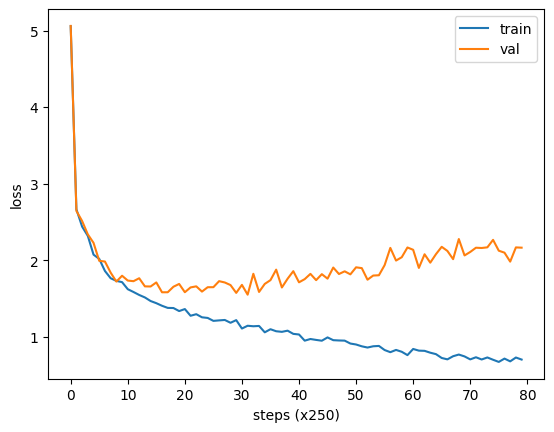

In [15]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend()
plt.xlabel('steps (x250)')
plt.ylabel('loss')
plt.show()